In [1]:
import os 
os.chdir('../../')

In [3]:
from backbones.pixart_alpha import PixArtAlpha

# 사용 예
model = PixArtAlpha()
print(model)

2025-09-17 15:29:22.292686: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Some weights of the model checkpoint at /home/scpark/.cache/huggingface/hub/models--PixArt-alpha--PixArt-XL-2-512x512/snapshots/50f702106901db6d0f8b67eb88e814c56ded2692/transformer were not used when initializing PixArtTransformer2DModel: 
 ['caption_projection.y_embedding']
`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [4]:
import matplotlib.pyplot as plt

def show_compare(imgs):
    fig, axes = plt.subplots(1, len(imgs), figsize=(18, 10))
    for i in range(len(imgs)):
        axes[i].imshow(imgs[i]); axes[i].axis('off');
    plt.tight_layout()
    plt.show()


In [5]:
PROMPTS = [
    "Misty alpine lake at dawn, clouds hugging peaks; weathered wooden rowboat tied to a post; contemplative, cinematic calm; slate blue, teal, soft gold; cool, airy, reflective; fine water ripples, gauzy fog",
    "Neon backstreet after rain, signs flickering; steaming ramen cart with three stools; gritty, intimate night energy; magenta, cyan, amber; slick, humid, electric; wet asphalt sheen, mirror reflections",
    "Snowbound pine forest at blue hour; red fox paused mid-step; hushed, vigilant stillness; silver, ice blue, auburn; crisp, brittle, clean; powder snow flurries, frosted needles",
    "Wind-sculpted desert dunes under stars; lone camel caravan on a ridge; vast, timeless wonder; warm sand, indigo, starlight white; dry, airy, meditative; fine sand grain, soft dune ripples",
    "Wave-battered cliffs with lighthouse beam; lantern rotating through spray; steadfast, hopeful resilience; cobalt, ivory, storm gray; brisk, salty, invigorating; sea mist droplets, rough basalt",
    "Sunlit antique library of tall windows; open atlas on an oak table; studious, nostalgic quiet; sepia, honey, forest green; warm, dusty, learned; paper fibers, leather grain",
    "Fog-shrouded suspension bridge at dawn; cyclist silhouette mid-span; solitary, cinematic suspense; steel gray, pale blue, sodium orange; cool, damp, resonant; riveted metal, beading droplets",
    "Coral canyon pierced by sun shafts; sea turtle gliding through schools; gentle, curious serenity; turquoise, coral, lemon; fluid, weightless, bright; suspended bubbles, reef roughness",
    "Black lava plain with glowing flows; geologist tripod near rim; intense, perilous focus; crimson, obsidian, ember orange; hot, radiant, tense; molten crust, heat shimmer",
    "Twilight medieval market stone square; minstrel playing lute on barrel; lively, communal warmth; wine red, ochre, candle gold; festive, rustic, cozy; worn fabrics, cobblestone texture",
    "Rooftop greenhouse beneath vast skyline; beekeeper tending wooden hives; caring, sustainable optimism; leaf green, honey, concrete gray; gentle, precise, patient; wax comb, glass condensation",
    "Pre-dawn alpine village bakery glow; trays of steaming loaves; welcoming, homey comfort; butter yellow, flour white, brick red; warm, yeasty, soft; crust scoring, burlap weave",
    "Frozen fjord under low aurora curtains; Viking longship nudging ice; stoic, mythic resolve; steel blue, emerald, moon white; crisp, biting, noble; jagged ice plates, carved wood",
    "Rain-polished boulevard with taxis; couple under clear umbrella; romantic, cinematic glow; chrome, neon cyan, rose; slick, humid, tender; puddle mirrors, glass bead rain",
    "High canyon overlook at sunset; condor circling warm thermals; awe, silent grandeur; burnt sienna, violet, gold; dry, expansive, elevated; layered striations, distant haze",
    "Morning-hazed cherry orchard in bloom; ladder leaned against a bough; cheerful, spring-fresh hope; blush pink, mint, cream; fragrant, airy, delicate; petal drift, dewy bark",
    "Cyber megacity with arcing maglev lines; courier drone docking on balcony; sleek, efficient futurism; electric cyan, black, chrome; smooth, precise, high-tech; glossy panels, hologram noise",
    "Moon crater rim in stark sunlight; astronaut posed beside flag; isolated, heroic clarity; pewter, white, ultramarine; stark, dry, high-contrast; fine regolith dust, crisp shadows",
    "Jungle river bend layered with mist; narrow canoe nosing upstream; exploratory, patient focus; fern green, teak brown, fog white; humid, earthy, enveloping; dappled light, wet wood",
    "Gothic cathedral nave of soaring ribs; lone violinist practicing; reverent, slowly unfolding calm; indigo, ruby, amber; airy, sacred, resonant; cool stone, plush velvet case",
]


Coral canyon pierced by sun shafts; sea turtle gliding through schools; gentle, curious serenity; turquoise, coral, lemon; fluid, weightless, bright; suspended bubbles, reef roughness
logs/pixart_alpha/rn/s5/step_00020000.pt


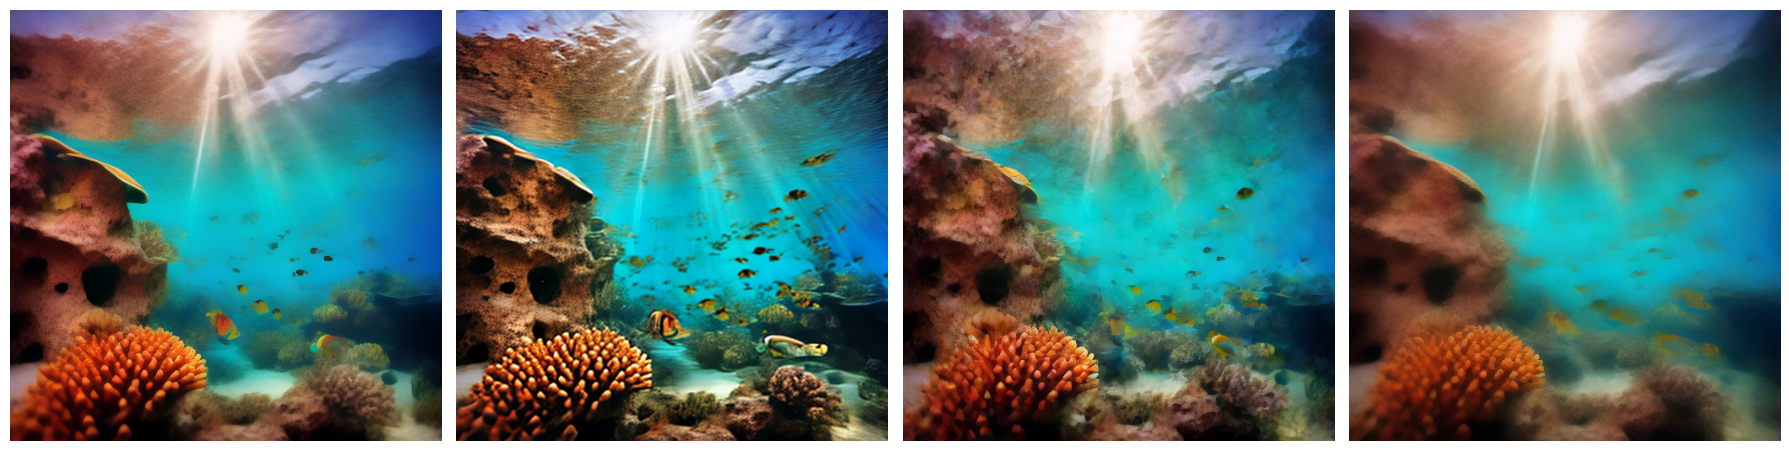

In [7]:
import torch

prompt = PROMPTS[7]
print(prompt)

noise_schedule = model.get_noise_schedule()
model_fn = model.get_model_fn(noise_schedule=noise_schedule, pos_conds=[prompt], guidance_scale=3.5)
latents = model.get_noise(seeds=[0])

NFE = 5

### DPM-Solver
from solvers.others.dpm_solver import DPM_Solver
solver = DPM_Solver(noise_schedule, steps=NFE, skip_type='time_uniform', algorithm_type="data_prediction")
dpm_latents = solver.sample(latents, model_fn)['samples']
dpm_samples = model.decode_vae(dpm_latents, pil_output=True)

### Dual-Solver
from solvers.taylor.solver.gdual_solver import GDual_Solver
from solvers.taylor.transform.logaffine_transform import LogAffineTransform
from solvers.taylor.extractor.table_extractor import Extractor
from utils.util import get_pt

with torch.no_grad():
    gdual = GDual_Solver(noise_schedule, steps=NFE, transform=LogAffineTransform(gamma_push=True, gamma_max=2, tau_offset=1, kappa_max=2, eps=1e-2),
                        param_extractor=Extractor(steps=NFE), skip_type="time_uniform", flow_shift=1.0,
                        pred_order=1, corr_order=2, order1_kappa=True, order2_kappa=True,
                        use_corrector=True, time_learning=True, train_mode=True).to(model.device)
    pt_file = get_pt(f'logs/pixart_alpha/rn/s{NFE}', label='latest')
    print(pt_file)
    gdual.load_state_dict(torch.load(pt_file, map_location='cpu', weights_only=False)['solver_state_dict'], strict=True)
    dual_latents = gdual.sample(latents, model_fn)['samples']
    dual_samples = model.decode_vae(dual_latents, pil_output=True)

from solvers.competing.bns.bns_solver_sep import BNS_Solver
from solvers.competing.ds.ds_solver_diffusion import DS_Solver

with torch.no_grad():
    bns = BNS_Solver(
                noise_schedule,
                steps=NFE,
                skip_type="time_uniform",
                algorithm_type='dual_prediction'
            ).to(model.device)

    pt_file = get_pt(f'logs/pixart_alpha/bns/s{NFE}/', label='latest')
    state_dict = torch.load(pt_file, map_location='cpu', weights_only=False)['solver_state_dict']
    bns.load_state_dict(state_dict, strict=True)
    bns_latents = bns.sample(latents, model_fn)['samples']
    bns_samples = model.decode_vae(bns_latents, pil_output=True)
    
    ds = DS_Solver(
        noise_schedule,
        steps=NFE,
        skip_type="time_uniform",
        algorithm_type='data_prediction'
    ).to(model.device)

    pt_file = get_pt(f'logs/pixart_alpha/ds/s{NFE}/', label='latest')
    state_dict = torch.load(pt_file, map_location='cpu', weights_only=False)['solver_state_dict']
    ds.load_state_dict(state_dict, strict=True)
    ds_latents = ds.sample(latents, model_fn)['samples']
    ds_samples = model.decode_vae(ds_latents, pil_output=True)
    
show_compare([dpm_samples['pil_output'][0], dual_samples['pil_output'][0], bns_samples['pil_output'][0], ds_samples['pil_output'][0]])




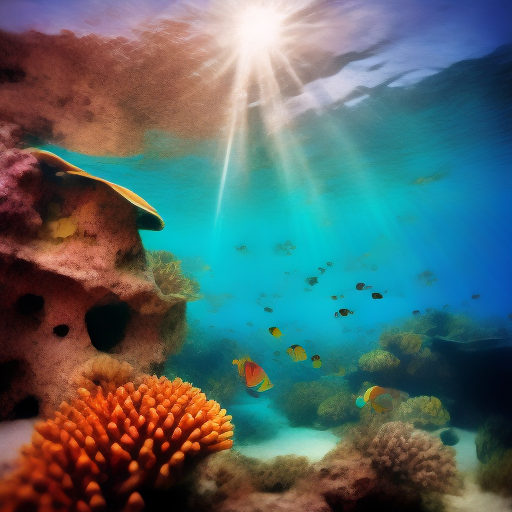

In [8]:
dpm_samples['pil_output'][0]

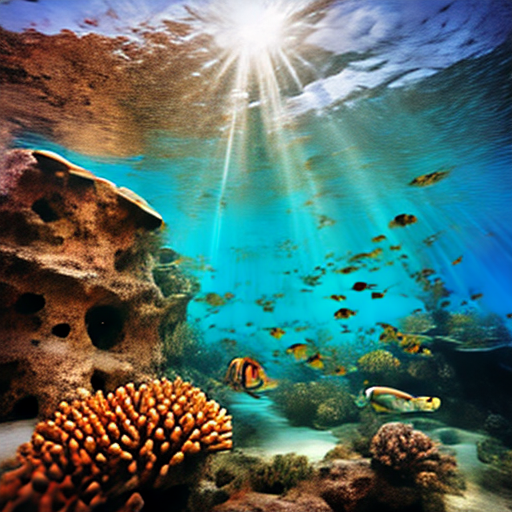

In [9]:
dual_samples['pil_output'][0]

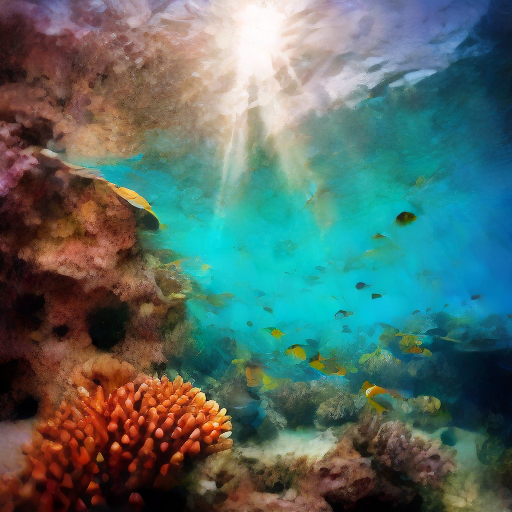

In [10]:
bns_samples['pil_output'][0]

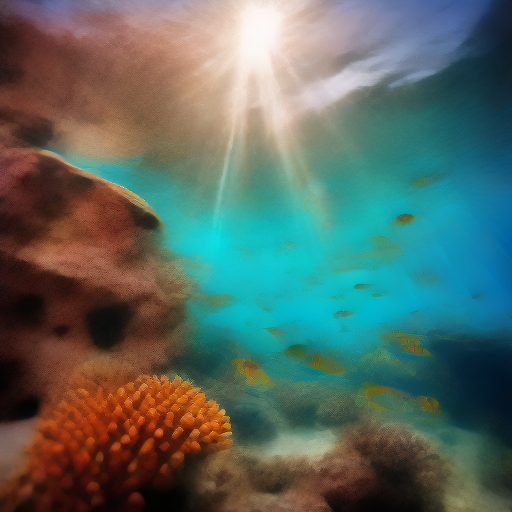

In [11]:
ds_samples['pil_output'][0]